<a href="https://colab.research.google.com/github/wikiwa1/ASD-with-SSL/blob/main/dataframesstftandlogmel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ── imports ──────────────────────────────────────────────────────────────────
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Audio, display

# ── global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('/content/drive/MyDrive/fan/')   # adjust if data lives elsewhere
MACHINE_IDS = ['id_00', 'id_02', 'id_04', 'id_06']
SR = 16_000               # native sample rate
CHANNEL = 0               # which mic channel to use (0–7); channel 0 is conventional

In [3]:
records = []
for machine_id in MACHINE_IDS:
    for label in ('normal', 'abnormal'):
        folder = DATA_ROOT / machine_id / label
        for wav in sorted(folder.glob('*.wav')):
            records.append({'machine_id': machine_id, 'label': label, 'path': wav})

manifest = pd.DataFrame(records)
print(manifest.columns.tolist())
print(len(records))
print(records[:3])
manifest['is_anomaly'] = (manifest['label'] == 'abnormal').astype(int)

print(f"Total files : {len(manifest):,}")
print()
print(manifest.groupby(['machine_id', 'label']).size().unstack(fill_value=0).assign(
    anomaly_rate=lambda d: (d['abnormal'] / (d['normal'] + d['abnormal'])).map('{:.1%}'.format)
))

['machine_id', 'label', 'path']
5550
[{'machine_id': 'id_00', 'label': 'normal', 'path': PosixPath('/content/drive/MyDrive/fan/id_00/normal/00000000.wav')}, {'machine_id': 'id_00', 'label': 'normal', 'path': PosixPath('/content/drive/MyDrive/fan/id_00/normal/00000001.wav')}, {'machine_id': 'id_00', 'label': 'normal', 'path': PosixPath('/content/drive/MyDrive/fan/id_00/normal/00000002.wav')}]
Total files : 5,550

label       abnormal  normal anomaly_rate
machine_id                               
id_00            407    1011        28.7%
id_02            359    1016        26.1%
id_04            348    1033        25.2%
id_06            361    1015        26.2%


In [ ]:
def load_mono(path, channel=CHANNEL, sr=SR):
    """Load a single channel from a MIMII WAV file. Returns 1-D float32 array."""
    audio, file_sr = sf.read(path, dtype='float32')
    assert file_sr == sr, f"Unexpected sample rate {file_sr} in {path}"
    return audio[:, channel] if audio.ndim == 2 else audio

for machine_id in ['id_04']:          # expand to other IDs as desired #this is how to access things in the dataframe
    for label in ('normal', 'abnormal'):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[5]
        y = load_mono(path)
        print(f"▶  {machine_id} / {label}")
        display(Audio(y, rate=SR))


▶  id_04 / normal


▶  id_04 / abnormal


**The short-time Fourier transform (STFT)** is a Fourier-related transform used to determine the sinusoidal frequency and phase content of local sections of a signal as it changes over time. In practice, the procedure for computing STFTs is to divide a longer time signal into shorter segments of equal length and then compute the Fourier transform separately on each shorter segment. This reveals the Fourier spectrum on each shorter segment. One then usually plots the changing spectra as a function of time, known as a spectrogram or waterfall plot, such as commonly used in software defined radio (SDR) based spectrum displays. Full bandwidth displays covering the whole range of an SDR commonly use fast Fourier transforms (FFTs). - Source: Wikipedia

In [ ]:
import librosa
import numpy as np

for machine_id in ['id_04']:          # expand to other IDs as desired #this is how to access things in the dataframe
    for label in ('normal', 'abnormal'):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[5]
y, sr = librosa.load(path, sr=22050)   # load waveform

D = librosa.stft(y, n_fft=2048, hop_length=512, window='hann')
magnitude = np.abs(D)          # shape: (freq_bins, time_frames)

# convert to log-mel from here:
mel = librosa.feature.melspectrogram(S=magnitude**2, sr=sr, n_mels=128)
log_mel = librosa.power_to_db(mel)

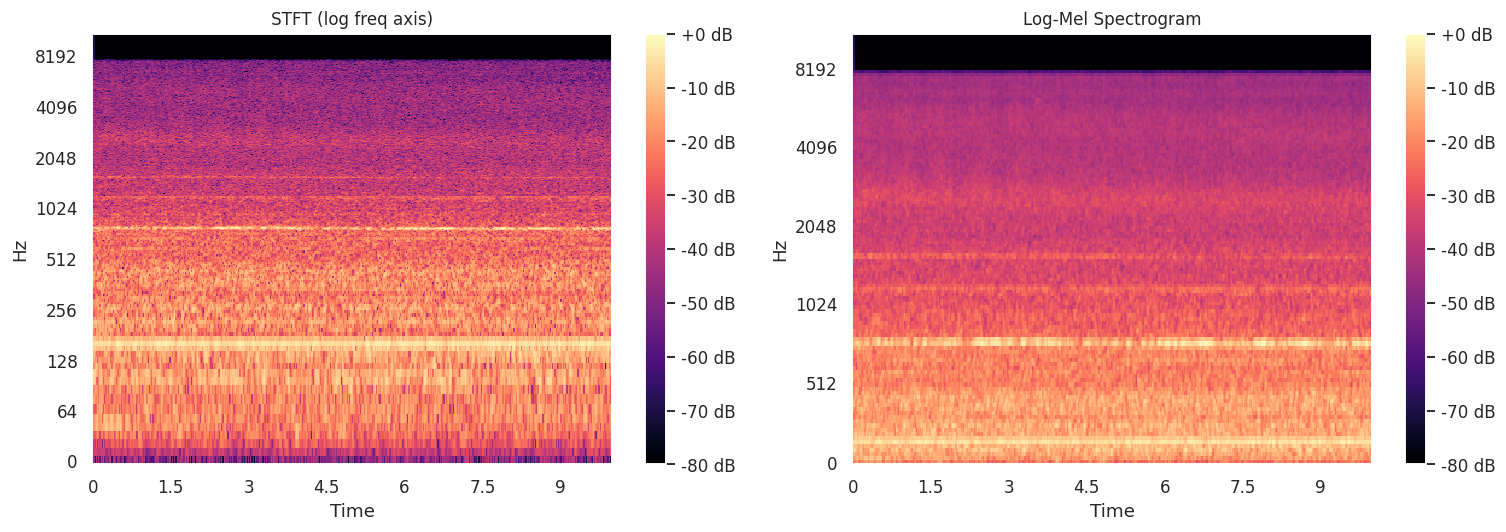

In [4]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

for machine_id in ['id_04']:          # expand to other IDs as desired #this is how to access things in the dataframe
    for label in ('normal', 'abnormal'):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[5]

y, sr = librosa.load(path, sr=22050)

# --- STFT ---
D = librosa.stft(y, n_fft=2048, hop_length=512, window='hann')
magnitude_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)  # log scale for viewing

# --- Log-mel ---
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
log_mel = librosa.power_to_db(mel, ref=np.max)

# --- Plot side by side ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

img1 = librosa.display.specshow(magnitude_db, sr=sr, hop_length=512,
                                  x_axis='time', y_axis='log', ax=ax[0])
ax[0].set_title('STFT (log freq axis)')
fig.colorbar(img1, ax=ax[0], format='%+2.0f dB')

img2 = librosa.display.specshow(log_mel, sr=sr, hop_length=512,
                                  x_axis='time', y_axis='mel', ax=ax[1])
ax[1].set_title('Log-Mel Spectrogram')
fig.colorbar(img2, ax=ax[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [ ]:
print(type(magnitude_db))
print(type(log_mel))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [5]:
from tqdm import tqdm

df = manifest.copy()
def compute_stft(path, n_fft=2048, hop_length=512):
    y, sr = librosa.load(path, sr=None)
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    return np.abs(D)   # magnitude spectrogram

def compute_logmel(path, n_fft=2048, hop_length=512, n_mels=128):
    y, sr = librosa.load(path, sr=None)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                          hop_length=hop_length, n_mels=n_mels)
    return librosa.power_to_db(mel, ref=np.max)

# df is your original dataframe with machine_id, label, path

stft_df = df.copy()
stft_df['stft'] = [compute_stft(p) for p in tqdm(df['path'])]
stft_df['stft'] = df['path'].apply(compute_stft)
stft_df = stft_df.drop(columns='path')

#logmel_df = df.copy()
#logmel_df['logmel'] = df['path'].apply(compute_logmel)
#logmel_df = logmel_df.drop(columns='path')





100%|██████████| 5550/5550 [34:33<00:00,  2.68it/s]


In [6]:
stft_df.to_pickle('/content/drive/MyDrive/fan/stft_df.pkl')

Access it later using stft_df = pd.read_pickle('/content/drive/MyDrive/fan/stft_df.pkl')

In [7]:
logmel_df = df.copy()
logmel_df['logmel'] = [compute_logmel(p) for p in tqdm(df['path'])]
logmel_df['logmel'] = df['path'].apply(compute_logmel)
logmel_df = logmel_df.drop(columns='path')

100%|██████████| 5550/5550 [05:26<00:00, 17.02it/s]


In [8]:
logmel_df.to_pickle('/content/drive/MyDrive/fan/logmel_df.pkl')